# **Health Insurance Price Prediction**

### **Problem Statement**

The goal of this project is to develop a **predictive model** that accurately estimates the **medical insurance costs** for individuals based on various **demographic, lifestyle, and health-related factors**. By applying machine learning techniques, we aim to assist **insurance companies** in better understanding their risk profiles and help individuals gain insights into how different factors influence their **insurance premiums**.

### **Import libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **Load dataset**

In [2]:
data = pd.read_csv('insurance.csv')
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


### **Understand the Variables**

**Domain Analysis**
The descriptions of the variables based on the insurance dataset:

1. **Age**
   - **Description:** Age of the primary beneficiary covered by health insurance.
   - **Type:** Continuous numerical variable.

2. **Sex**
   - **Description:** Gender of the insurance contractor.
   - **Type:** Categorical variable with two levels: female, male.

3. **BMI (Body Mass Index)**
   - **Description:** Body mass index, which is a measure of body fat based on height and weight.
   - **Type:** Continuous numerical variable.
   - **Ideal Range:** Ideally between 18.5 to 24.9 kg/m².

4. **Children**
   - **Description:** Number of children covered by health insurance or number of dependents.
   - **Type:** Discrete numerical variable.

5. **Smoker**
   - **Description:** Binary indicator if the beneficiary is a smoker.
   - **Type:** Categorical variable with two levels: yes, no.

6. **Region**
   - **Description:** The beneficiary's residential area in the US.
   - **Type:** Categorical variable with four levels: northeast, southeast, southwest, northwest.

7. **Charges**
   - **Description:** Individual medical costs billed by health insurance.
   - **Type:** Continuous numerical variable.

### **Basic Checks**

In [3]:
# find number of rows and columns
data.shape

(1338, 7)

There are 1338 rows and 7 columns.

In [4]:
# print first 5 rows
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
# print last 5 rows
data.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [6]:
# check info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
# check data type
data.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [8]:
# print all columns
data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [9]:
# print numerical columns
num_data = data.select_dtypes(include=['int64','float64'])
num_data

,age,bmi,children,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,28,33.000,3,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520
...,...,...,...,...
1333,50,30.970,3,10600.54830
1334,18,31.920,0,2205.98080
1335,18,36.850,0,1629.83350
1336,21,25.800,0,2007.94500


In [10]:
# print categorical columns
cat_data = data.select_dtypes(include='object')
cat_data

,sex,smoker,region
0,female,yes,southwest
1,male,no,southeast
2,male,no,southeast
3,male,no,northwest
4,male,no,northwest
...,...,...,...
1333,male,no,northwest
1334,female,no,northeast
1335,female,no,southeast
1336,female,no,southwest


In [11]:
# get the statistical report for numerical data
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [12]:
#get the statistical report for categorical data
data.describe(include='object')

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


In [13]:
# check unique values
for x in cat_data:
  print(x , '-->' , data[x].unique())

sex --> ['female' 'male']
smoker --> ['yes' 'no']
region --> ['southwest' 'southeast' 'northwest' 'northeast']


In [14]:
# check Value Counts
for x in cat_data:
  print(data[x].value_counts())
  print()

sex
male      676
female    662
Name: count, dtype: int64

smoker
no     1064
yes     274
Name: count, dtype: int64

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64



### **Data Cleaning**

**Check for Missing Values**

In [15]:
data.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


No missing values in a data.

**Check for duplicates**

In [16]:
data.duplicated().sum()

np.int64(1)

There is 1 duplicate in a data.

**Drop duplicates**

In [17]:
data.drop_duplicates(inplace=True)

In [18]:
data.duplicated().sum()

np.int64(0)

## **Exploratory Data Analysis**

**Check the distribution of charges**

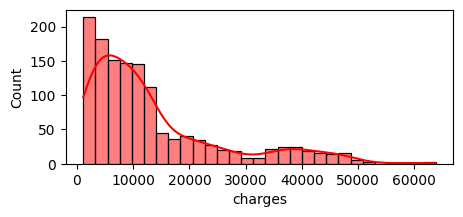

In [19]:
plt.figure(figsize=(5,2))
sns.histplot(data,x='charges',kde=True,color='red')
plt.show()

**Check the distribution of BMI**

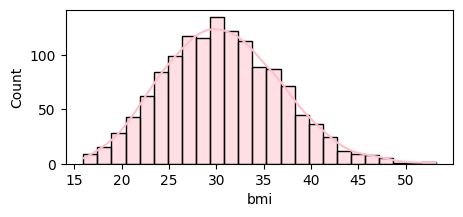

In [20]:
plt.figure(figsize=(5,2))
sns.histplot(data,x='bmi',kde=True,color='pink')
plt.show()

**Check the distribution of Age**

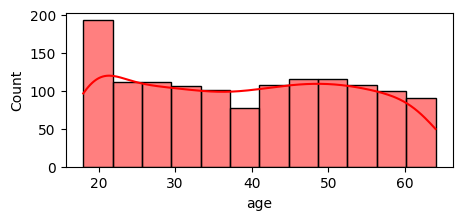

In [21]:
plt.figure(figsize=(5,2))
sns.histplot(data,x='age',kde=True,color='red')
plt.show()

**How many customers are Smoker or non smokers**

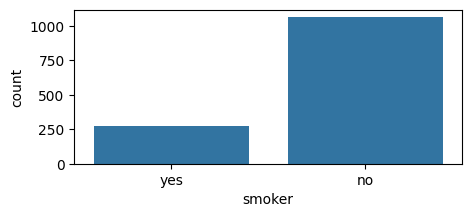

In [22]:
plt.figure(figsize=(5,2))
sns.countplot(data,x='smoker')
plt.show()

**How many customers are male or female**

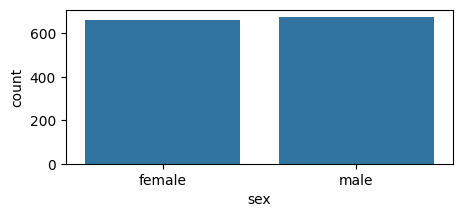

In [23]:
plt.figure(figsize=(5,2))
sns.countplot(data,x='sex')
plt.show()

**How many customers are from different region**

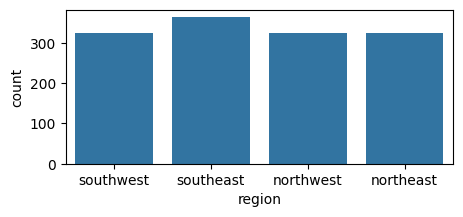

In [24]:
plt.figure(figsize=(5,2))
sns.countplot(data,x='region')
plt.show()

**Check are there any outliers in age,bmi and charges**

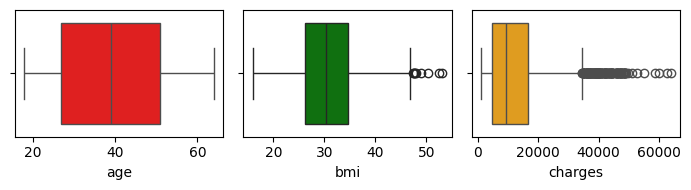

In [25]:
fig , ax = plt.subplots(1,3,figsize=(7,2))
sns.boxplot(data , x='age',ax=ax[0],color='red')
sns.boxplot(data,x='bmi',ax=ax[1],color='green')
sns.boxplot(data,x='charges',ax=ax[2],color='orange')
plt.tight_layout()

**Find relationship between age and charges**

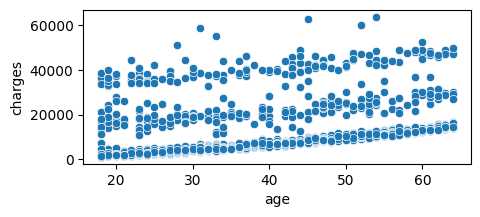

In [26]:
plt.figure(figsize=(5,2))
sns.scatterplot(data,x='age',y='charges')
plt.show()

**Find relationship between bmi and charges**

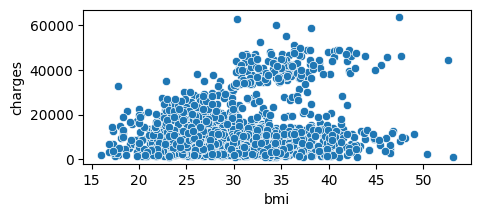

In [27]:
plt.figure(figsize=(5,2))
sns.scatterplot(data,x='bmi',y='charges')
plt.show()

**Check how charges vary with Gender**

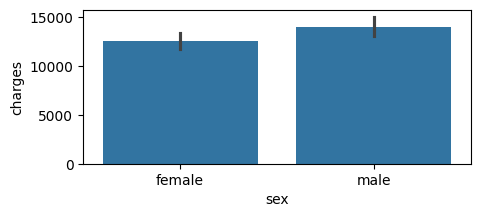

In [28]:
plt.figure(figsize=(5,2))
sns.barplot(data,x='sex',y='charges')
plt.show()

**Check how charges vary with smokers or non smokers**

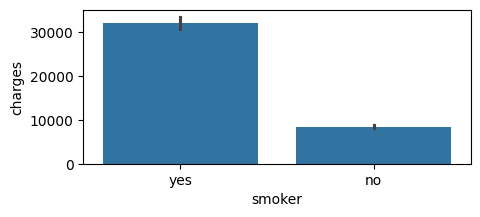

In [29]:
plt.figure(figsize=(5,2))
sns.barplot(data,x='smoker',y='charges')
plt.show()

**Pairplot**

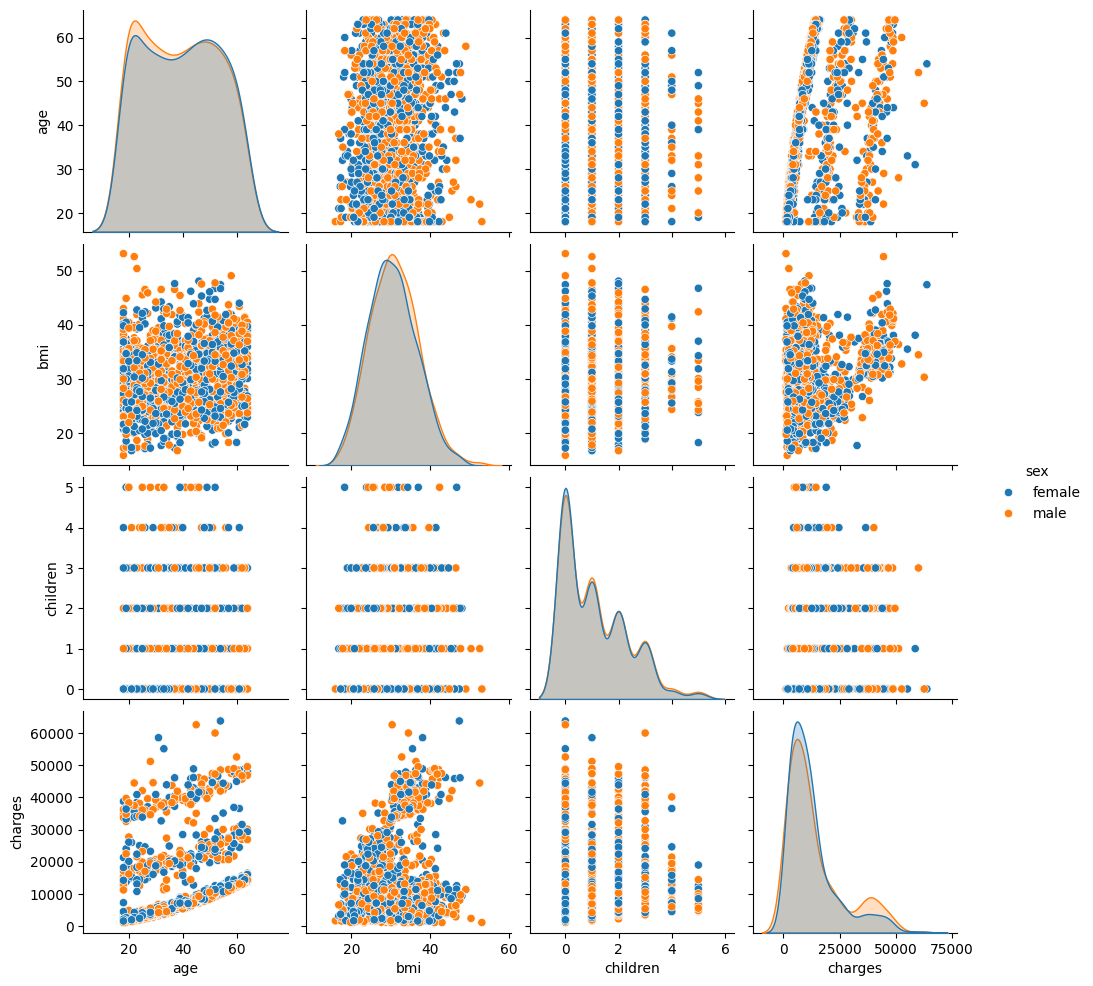

In [30]:
sns.pairplot(data,hue='sex')

**Heat Map**

<Axes: >

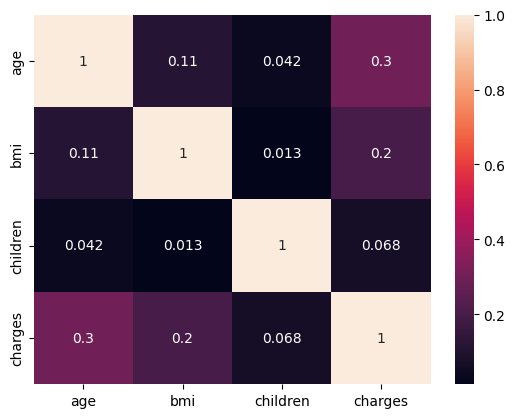

In [31]:
sns.heatmap(num_data.corr(),annot=True)

## **Handle Outliers**

Outliers are extreme values which are different from actual data.

**Check the direction of outliers in numerical columns**

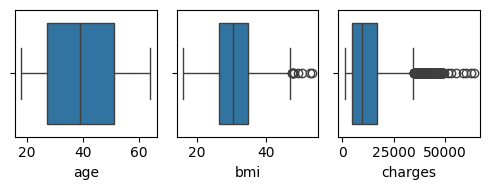

In [32]:
fig,ax = plt.subplots(1,3,figsize=(5,2))
sns.boxplot(data,x='age',ax=ax[0])
sns.boxplot(data,x='bmi',ax=ax[1])
sns.boxplot(data,x='charges',ax=ax[2])
plt.tight_layout()

Outliers are seen in bmi and charges

**Check the distribution of bmi and charges**

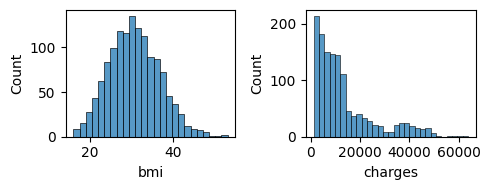

In [33]:
fig,ax = plt.subplots(1,2,figsize=(5,2))
sns.histplot(data,x='bmi',ax=ax[0])
sns.histplot(data,x='charges',ax=ax[1])
plt.tight_layout()

* Distributon of bmi is normal.
* Distribution of charges is right skewed.

In [34]:
data['bmi'].skew()

np.float64(0.28391419385321137)

In [35]:
data['charges'].skew()

np.float64(1.5153909108403483)

**Ways to find outlier values**

1. IQR : Used when data distribution is skewed.
2. 3-sigma rule : Used when data is normal
3. Outliers should be removed or replaced only if % is less than 5%.

## **IQR**
Charges distribution is skewed hence we go with IQR method to find outliers.
1. Find Q1
2. Find Q3
3. IQR = Q3-Q1
4. lower_limit = Q1-1.5*IQR
5. upper_limit = Q3+1.5*IQR
6. If any value in charges is less than lower limit and greater than upper limit then its an outlier.


In [36]:
# find outliers in charges
Q1 = data.loc[:,'charges'].quantile(0.25)
Q3 = data.loc[:,'charges'].quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5* IQR


In [37]:
# filter values less than lower limit
data[data.loc[:,'charges']<lower_limit]

,age,sex,bmi,children,smoker,region,charges


In [38]:
# filter values greater than upper limit
data[data.loc[:,'charges']>upper_limit]

,age,sex,bmi,children,smoker,region,charges
14,27,male,42.130,0,yes,southeast,39611.75770
19,30,male,35.300,0,yes,southwest,36837.46700
23,34,female,31.920,1,yes,northeast,37701.87680
29,31,male,36.300,2,yes,southwest,38711.00000
30,22,male,35.600,0,yes,southwest,35585.57600
...,...,...,...,...,...,...,...
1300,45,male,30.360,0,yes,southeast,62592.87309
1301,62,male,30.875,3,yes,northwest,46718.16325
1303,43,male,27.800,0,yes,southwest,37829.72420
1313,19,female,34.700,2,yes,southwest,36397.57600


In [39]:
# Over all
data[(data.loc[:,'charges']<lower_limit)|(data.loc[:,'charges']>upper_limit)]

,age,sex,bmi,children,smoker,region,charges
14,27,male,42.130,0,yes,southeast,39611.75770
19,30,male,35.300,0,yes,southwest,36837.46700
23,34,female,31.920,1,yes,northeast,37701.87680
29,31,male,36.300,2,yes,southwest,38711.00000
30,22,male,35.600,0,yes,southwest,35585.57600
...,...,...,...,...,...,...,...
1300,45,male,30.360,0,yes,southeast,62592.87309
1301,62,male,30.875,3,yes,northwest,46718.16325
1303,43,male,27.800,0,yes,southwest,37829.72420
1313,19,female,34.700,2,yes,southwest,36397.57600


In [40]:
# find %
len(data[(data.loc[:,'charges']<lower_limit)|(data.loc[:,'charges']>upper_limit)])/len(data)*100

10.396409872849663

Since % of outliers are more than 5% i.e 10% they are not outliers they are adding some meaning to the data.

## **3 sigma rule**
The distribution of bmi is normal hence we find outliers using 3 sigma rule.

1. find mean
2. find standard deviation
3. lower_limit = mean - 3* std
4. upper_limit = mean + 3*std
5. If any value less than lower_limit or greater than upper limit is considered as outlier.

In [41]:
mean_val = data.loc[:,'bmi'].mean()
std_val = data.loc[:,'bmi'].std()
lower_limit = mean_val - 3* std_val
upper_limit = mean_val  + 3* std_val

In [42]:
# filter all the values less than lower
data[data.loc[:,'bmi']<lower_limit]

,age,sex,bmi,children,smoker,region,charges


In [43]:
# filter values greater than upper
# filter all the values less than lower
data[data.loc[:,'bmi']> upper_limit]

,age,sex,bmi,children,smoker,region,charges
116,58,male,49.06,0,no,southeast,11381.3254
847,23,male,50.38,1,no,southeast,2438.0552
1047,22,male,52.58,1,yes,southeast,44501.3982
1317,18,male,53.13,0,no,southeast,1163.4627


In [44]:
# filter values that are less than lower or greater than upper
data[(data.loc[:,'bmi']<lower_limit) | (data.loc[:,'bmi']> upper_limit)]

,age,sex,bmi,children,smoker,region,charges
116,58,male,49.06,0,no,southeast,11381.3254
847,23,male,50.38,1,no,southeast,2438.0552
1047,22,male,52.58,1,yes,southeast,44501.3982
1317,18,male,53.13,0,no,southeast,1163.4627


In [45]:
# find percentage
len(data[(data.loc[:,'bmi']<lower_limit) | (data.loc[:,'bmi']> upper_limit)])/len(data)*100

0.2991772625280479

Since % of outliers are ver less 0.2% lets fill with mean.

In [46]:
# fill with mean
data.loc[(data.loc[:,'bmi']<lower_limit) | (data.loc[:,'bmi']>
                                            upper_limit),'bmi']=data.loc[:,'bmi'].mean()

In [47]:
len(data[(data.loc[:,'bmi']<lower_limit) | (data.loc[:,'bmi']> upper_limit)])/len(data)*100

0.0

## **Encoding**
Process of converting text into numbers.
* Label Encoder
* One hot Encoder
* Ordinal Encoder
* Manual Encoder

**Smoker**

In [48]:
# Label Encoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data.loc[:,'Smoker']=le.fit_transform(data.loc[:,'smoker'])


In [49]:
data.drop(columns='smoker',inplace=True)

In [50]:
data.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
region,object
charges,float64
Smoker,int64


**Sex**

In [51]:
# one hot encoder
data =pd.get_dummies(data,columns=['sex'],dtype='int')
data

,age,bmi,children,region,charges,Smoker,sex_female,sex_male
0,19,27.900,0,southwest,16884.92400,1,1,0
1,18,33.770,1,southeast,1725.55230,0,0,1
2,28,33.000,3,southeast,4449.46200,0,0,1
3,33,22.705,0,northwest,21984.47061,0,0,1
4,32,28.880,0,northwest,3866.85520,0,0,1
...,...,...,...,...,...,...,...,...
1333,50,30.970,3,northwest,10600.54830,0,0,1
1334,18,31.920,0,northeast,2205.98080,0,1,0
1335,18,36.850,0,southeast,1629.83350,0,1,0
1336,21,25.800,0,southwest,2007.94500,0,1,0


**region**

In [52]:
data.loc[:,'region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

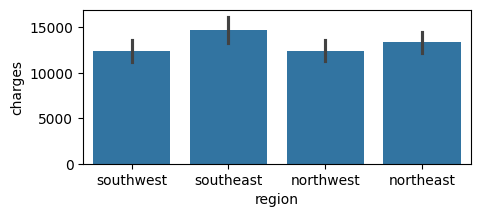

In [53]:
# target encoding
# relationship between region and charges
plt.figure(figsize=(5,2))
sns.barplot(data , x='region',y='charges')
plt.show()

In [54]:
# southeast: 3 , northeast:2 , northwest : 1 , southwest=0
data.loc[:,'Region']=data.loc[:,'region'].map({'southeast':3,'northeast':2,'northwest':1,'southwest':0})


In [55]:
data.drop(columns='region',inplace=True)

In [56]:
data

,age,bmi,children,charges,Smoker,sex_female,sex_male,Region
0,19,27.900,0,16884.92400,1,1,0,0
1,18,33.770,1,1725.55230,0,0,1,3
2,28,33.000,3,4449.46200,0,0,1,3
3,33,22.705,0,21984.47061,0,0,1,1
4,32,28.880,0,3866.85520,0,0,1,1
...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,0,0,1,1
1334,18,31.920,0,2205.98080,0,1,0,2
1335,18,36.850,0,1629.83350,0,1,0,3
1336,21,25.800,0,2007.94500,0,1,0,0


## **Scaling**
Scaling brings all the numerical column values into a same scale so that calculations become easy for ML algorithms

- Min max scaler : It brings everything to a range of 0 to 1
- Standard scaler : It make mean =0 , std = 1 for the column

**MinMax Scaler**

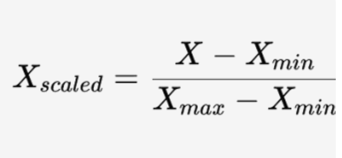

In [57]:
df1 = data.copy()

In [58]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df1[['age']]=scaler.fit_transform(df1[['age']])
df1[['bmi']]=scaler.fit_transform(df1[['bmi']])

**Standard Scaler**

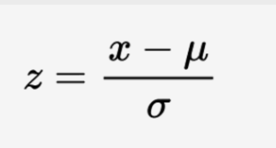

In [59]:
df2 = data.copy()


In [60]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df2[['age']]=scaler.fit_transform(df2[['age']])
df2[['bmi']]=scaler.fit_transform(df2[['bmi']])

In [61]:
# age , bmi
data

,age,bmi,children,charges,Smoker,sex_female,sex_male,Region
0,19,27.900,0,16884.92400,1,1,0,0
1,18,33.770,1,1725.55230,0,0,1,3
2,28,33.000,3,4449.46200,0,0,1,3
3,33,22.705,0,21984.47061,0,0,1,1
4,32,28.880,0,3866.85520,0,0,1,1
...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,0,0,1,1
1334,18,31.920,0,2205.98080,0,1,0,2
1335,18,36.850,0,1629.83350,0,1,0,3
1336,21,25.800,0,2007.94500,0,1,0,0


## **Transformation**

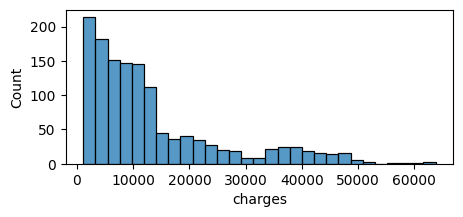

In [62]:
# Linear Regression expect target to be a normal
plt.figure(figsize=(5,2))
sns.histplot(data,x='charges')
plt.show()


In [63]:
# convreting skewed to normal is possible with log
df2[['charges']]=np.log(df2[['charges']])

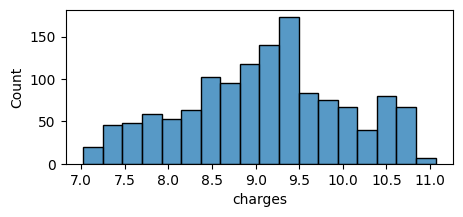

In [64]:
plt.figure(figsize=(5,2))
sns.histplot(df2,x='charges')
plt.show()

## **Feature Engineering**
- Selecting best features
- removing features which are not important
- creating new features

In [65]:
df = data[['age','bmi','charges','children']]


<Axes: >

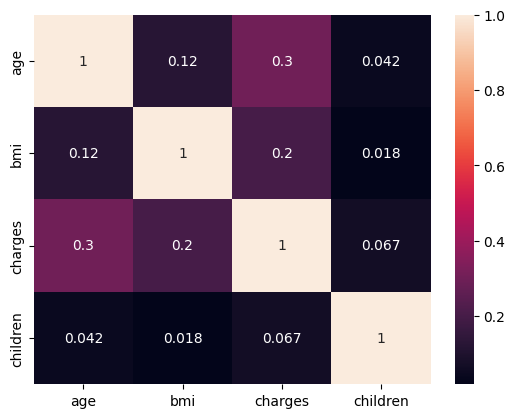

In [66]:
sns.heatmap(df.corr(),annot=True)

- Include columns which has high correlation with target and drop the column which has less correlation.
- Check correlation among input features.
- If any two features representing high correlation we can drop one of them.

## **Split data for X and Y**

In [67]:
x= df2.drop(columns='charges')
y = df2.loc[:,'charges']

## **Split data for training and testing**

In [68]:
# 70:30 or 80:20
# xtrain , xtest
# ytrain , ytest
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [69]:
data.shape

(1337, 8)

In [70]:
x_train.shape

(1069, 7)

In [71]:
x_test.shape

(268, 7)

In [72]:
y_train.shape


(1069,)

In [73]:
y_test.shape

(268,)

## **Model Building**

In [74]:
# import Linear Regression model
from sklearn.linear_model import LinearRegression
# initialise the model
model = LinearRegression()
# train the model :x_train,y_train
model.fit(x_train,y_train)

LinearRegression()

In [75]:
# Make predictions/Testing : x_test
y_pred=model.predict(x_test)

In [76]:
# slope
model.coef_

array([ 0.47807197,  0.07022415,  0.09974901,  1.53348832,  0.03628723,
       -0.03628723, -0.0030693 ])

In [77]:
# intercept
model.intercept_

np.float64(8.684654352299868)

## **Evaluate the Model**
* MSE
* MAE
* RMSE
* MAPE
* r2 score
* adjusted r2 score

In [78]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,mean_absolute_percentage_error,r2_score

In [79]:
# y_test,y_pred
# mean square error
mse=mean_squared_error(y_test,y_pred)
mse

0.16605874894057412

In [80]:
# mean absolute error
mae = mean_absolute_error(y_test,y_pred)
mae

0.26879992937118125

In [81]:
# root mean squared error
rmse = np.sqrt(mse)
rmse

np.float64(0.407503066173218)

In [82]:
# mean absolute percentage error
mape = mean_absolute_percentage_error(y_test,y_pred)
mape

0.029824414276419967

In [83]:
# r2 score
r2=r2_score(y_test,y_pred)
r2

0.821092095582562

82% better model.

In [84]:
# adjusted r2 score
# adj = 1-(1-r2)(n-1)/(n-p-1)
n = x_test.shape[0]
n # number of samples in test data

268

In [85]:
p = x_test.shape[1]
p # number of input columns

7

In [86]:
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.8162753443097849

# **KNN Regressor**

In [87]:
from sklearn.neighbors import KNeighborsRegressor
model = KNeighborsRegressor(n_neighbors=3)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [88]:
# mse
mean_squared_error(y_test,y_pred)

0.2648697019018715

In [89]:
#mae
mean_absolute_error(y_test,y_pred)

0.3291875562039706

In [90]:
# rmse
np.sqrt(mse)

np.float64(0.407503066173218)

In [91]:
#mape
mean_absolute_percentage_error(y_test,y_pred)

0.03529979166578674

In [92]:
# r2 score
r2 = r2_score(y_test,y_pred)
r2

0.7146354310552265

In [93]:
# adjusted r2 score
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.7069525388144058

# Decision Tree Regressor

In [94]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor(criterion='squared_error',max_depth=6,max_features='sqrt',min_samples_split=5,min_samples_leaf=3)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)


In [95]:
# mean squared error
mean_squared_error(y_test,y_pred)

0.2737911483506915

In [96]:
# mean absolute error
mean_absolute_error(y_test,y_pred)

0.35906806595775825

In [97]:
# root mean squared error
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(0.5232505598188038)

In [98]:
# mean absolute percentage error
mean_absolute_percentage_error(y_test,y_pred)

0.040222865660506694

In [99]:
# r2 score
r2 = r2_score(y_test,y_pred)
r2

0.7050236683585078

In [100]:
# adjusted r2 score
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.6970819978912369

# K fold

In [101]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
model = DecisionTreeRegressor(criterion='squared_error',max_depth=6,max_features='sqrt',min_samples_split=5,min_samples_leaf=3)
kfold = KFold(n_splits=5,shuffle=True,random_state=42)
scores = cross_val_score(model,x_train,y_train,cv=kfold)

In [102]:
scores

array([0.60304656, 0.37662311, 0.66404005, 0.49716607, 0.74386666])

In [103]:
print(np.mean(scores))

0.576948491827926


# Stratified K Fold


In [104]:
from sklearn.model_selection import StratifiedKFold
model = DecisionTreeRegressor(criterion='squared_error',max_depth=6,max_features='sqrt',min_samples_split=5,min_samples_leaf=3)
sfold = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
scores = cross_val_score(model,x_train,y_train)

In [105]:
scores

array([0.62552152, 0.45740013, 0.63950703, 0.79133607, 0.74130533])

In [106]:
print(np.mean(scores))

0.6510140182575721


# Random Forest Regressor

In [107]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=10,max_depth=6,max_features=5,bootstrap=True,min_samples_split=5,min_samples_leaf=3)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
'''
n_estimators=10,max_depth=6,max_features=5,
bootstrap=True,min_samples_split=5,min_samples_leaf=3'''

'\nn_estimators=10,max_depth=6,max_features=5,\nbootstrap=True,min_samples_split=5,min_samples_leaf=3'

In [108]:
mean_squared_error(y_test,y_pred)

0.11641297037852674

In [109]:
mean_absolute_error(y_test,y_pred)

0.1922272520420476

In [110]:
np.mean(mean_squared_error(y_test,y_pred))

np.float64(0.11641297037852674)

In [111]:
mean_absolute_percentage_error(y_test,y_pred)

0.021485672722440972

In [112]:
r2 = r2_score(y_test,y_pred)
r2

0.8745793238218076

In [113]:
# adjusted r2 score
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.8712026133093178

# Gradient Boosting Regressor

In [114]:
from sklearn.ensemble import GradientBoostingRegressor
model=GradientBoostingRegressor()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [115]:
mean_squared_error(y_test,y_pred)

0.10704710607807359

In [116]:
mean_absolute_error(y_test,y_pred)

0.18569810322355818

In [117]:
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(0.32718054049419504)

In [118]:
mean_absolute_percentage_error(y_test,y_pred)

0.020578504131201398

In [119]:
r2 = r2_score(y_test,y_pred)
r2

0.884669892164291

In [120]:
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.8815648507994835

# XGBoost Regressor

In [121]:
from xgboost import XGBRegressor
model = XGBRegressor()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [122]:
mean_squared_error(y_test,y_pred)

0.18084456209005167

In [123]:
mean_absolute_error(y_test,y_pred)

0.23856106630559218

In [124]:
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(0.42525822989102946)

In [125]:
mean_absolute_percentage_error(y_test,y_pred)

0.026820148617544184

In [126]:
r2=r2_score(y_test,y_pred)
r2

0.8051621981061727

In [127]:
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.799916564978262

**Grid Search CV with gradient boosting**

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
model = GradientBoostingRegressor()
parameters = {'max_depth':[5,6,7],'n_estimators':[100,200,300],
              'learning_rate':[0.01,0.1,0.2]}
grid = GridSearchCV(estimator=model,param_grid=parameters,cv=5 )
grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=GradientBoostingRegressor(),
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [5, 6, 7],
                         'n_estimators': [100, 200, 300]})

In [ ]:
print(grid.best_params_)

{'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300}


In [ ]:
model = GradientBoostingRegressor(learning_rate=0.01,max_depth=5,n_estimators=300)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)


In [ ]:
mean_squared_error(y_test,y_pred)

0.11954831062868321

In [ ]:
r2_score(y_test,y_pred)

0.8712013798268672

**Randomised Search for Gradient Boosting**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
parameters = {'max_depth':[5,6,7],'n_estimators':[100,200,300],
              'learning_rate':[0.01,0.1,0.2]}
model = GradientBoostingRegressor()
random = RandomizedSearchCV(estimator=model,param_distributions=parameters,cv=5 , n_iter=10)
random.fit(x_train,y_train)

RandomizedSearchCV(cv=5, estimator=GradientBoostingRegressor(),
                   param_distributions={'learning_rate': [0.01, 0.1, 0.2],
                                        'max_depth': [5, 6, 7],
                                        'n_estimators': [100, 200, 300]})

In [ ]:
print(random.best_params_)

{'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01}


In [ ]:
model = GradientBoostingRegressor(n_estimators=300,max_depth=5,learning_rate=0.01)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
mean_squared_error(y_test,y_pred)

0.11954837134472128

In [ ]:
r2_score(y_test,y_pred)

0.8712013144127941

**XGBOOST Grid Search CV**

In [ ]:
from xgboost import XGBRegressor
model = XGBRegressor()
parameters = {'max_depth':[4,5,6],'n_estimators':[10,50,100,200,300],
              'learning_rate':[0.1,0.01,0.2],'reg_alpha':[0.1,0.01,0.2,0.3],
              'reg_lambda':[1,5,8,10]}
grid = GridSearchCV(estimator=model,param_grid=parameters,cv=5)
grid.fit(x_train,y_train)

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.1, 0.01, 0.2],
                         'max_depth': [4, 5, 6],
                         'n_estimators': [10, 50, 100, 200, 300],
                         'reg_alpha': [0.1, 0.01, 0.2, 0.3],
                         'reg_lambda': [1, 5, 8, 10]})

In [ ]:
print(grid.best_params_)

{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 50, 'reg_alpha': 0.1, 'reg_lambda': 10}


In [ ]:
model = XGBRegressor(learning_rate= 0.1,max_depth= 4,n_estimators=50,
                   reg_alpha=0.1,reg_lambda=10 )
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
mean_squared_error(y_test,y_pred)

0.10773879475710342

In [ ]:
r2_score(y_test,y_pred)

0.8839246825751307

**RandomizedSearch CV with XGBOOST**

In [ ]:

model = XGBRegressor()
parameters = {'max_depth':[4,5,6],'n_estimators':[10,50,100,200,300],
              'learning_rate':[0.1,0.01,0.2],'reg_alpha':[0.1,0.01,0.2,0.3],
              'reg_lambda':[1,5,8,10]}
random=RandomizedSearchCV(estimator=model,param_distributions=parameters,cv=5,n_iter=30)
random.fit(x_train,y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          max_delta_step=None, max_depth=None,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=30,
                   param_distributions={'learning_rate': [0.1, 0.01, 0.2],
                                        'max_depth': [4, 5, 6],
                                        'n_estimators': [10, 50, 100, 200, 300],
                                        'reg_alpha': [0.1, 0.01, 0.2, 0.3],
                                        'reg_lambda': [1, 5, 8, 10]})

In [ ]:
print(random.best_params_)

{'reg_lambda': 10, 'reg_alpha': 0.1, 'n_estimators': 50, 'max_depth': 6, 'learning_rate': 0.1}


In [ ]:
model = XGBRegressor(reg_lambda=10,reg_alpha= 0.1,n_estimators= 50,
                     max_depth= 6,learning_rate=0.1)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
n_squared_error(y_test,y_pred)mea

0.11409509459468825

In [ ]:
r2_score(y_test,y_pred)

0.8770765502662563

# Support vector Regressor

In [128]:
from sklearn.svm import SVR
model = SVR()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [129]:
mean_squared_error(y_test,y_pred)

0.11385996566196165

In [130]:
r2_score(y_test,y_pred)

0.8773298728095755

# Grid Search CV

In [134]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
model = SVR()
parameters ={'kernel':['linear','poly','rbf','sigmoid'],'C':[1,5,10,15],'gamma':[0.1,0.01,0.001]}
grid = GridSearchCV(estimator=model,param_grid=parameters,cv=5,scoring='r2')
grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=SVR(),
             param_grid={'C': [1, 5, 10, 15], 'gamma': [0.1, 0.01, 0.001],
                         'kernel': ['linear', 'poly', 'rbf', 'sigmoid']},
             scoring='r2')

In [135]:
print(grid.best_params_)

{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}


In [137]:
model = SVR(C=10,gamma=0.1,kernel='rbf')
model.fit(x_train,y_train)
y_pred = model.predict(x_test)


In [138]:
mean_squared_error(y_test,y_pred)

0.10318520607694713

In [139]:
r2_score(y_test,y_pred)

0.888830615045074

# randomized Search CV

RandomizedSearchCV(cv=5, estimator=SVR(),
                   param_distributions={'C': [1, 5, 10, 15],
                                        'gamma': [0.1, 0.01, 0.001],
                                        'kernel': ['linear', 'poly', 'rbf',
                                                   'sigmoid']},
                   scoring='r2')

In [141]:
print(random.best_params_)

{'kernel': 'rbf', 'gamma': 0.1, 'C': 10}


In [142]:
model = SVR(kernel='rbf',C=10,gamma=0.1)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [143]:
mean_squared_error(y_test,y_pred)


0.10318520607694713

In [144]:
r2_score(y_test,y_pred)

0.888830615045074